In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset('tips')

| **컬럼명** | **자료형** | **의미** |
| :--- | :--- | :--- |
| `total_bill` | float | 식사 대금 (총 청구액) |
| `tip` | float | 팁 금액 |
| `sex` | category | 계산한 사람의 성별 (`Male`, `Female`) |
| `smoker` | category | 일행 중 흡연자 포함 여부 (`Yes`, `No`) |
| `day` | category | 요일 (`Thur`, `Fri`, `Sat`, `Sun`) |
| `time` | category | 식사 시간 (`Lunch`, `Dinner`) |
| `size` | int | 테이블 인원 수 |

In [3]:
pivot_result = df.pivot_table(index='day',
                              values='total_bill',
                              aggfunc='mean',
                              observed=True)
pivot_result

,total_bill
day,
Thur,17.682742
Fri,17.151579
Sat,20.441379
Sun,21.410000


---
막대그래프

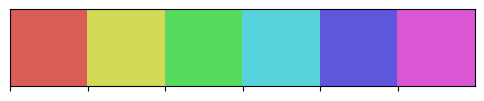

In [4]:
colors6 = sns.color_palette('hls')
sns.palplot(colors6)
plt.show()

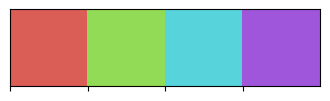

In [5]:
colors4 = sns.color_palette('hls', 4)
sns.palplot(colors4)
plt.show()

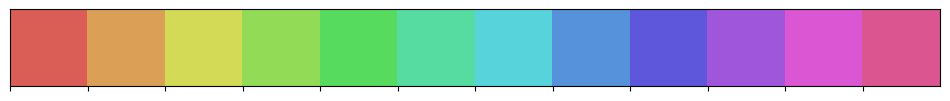

In [6]:
colors12 = sns.color_palette('hls', 12)
sns.palplot(colors12)
plt.show()

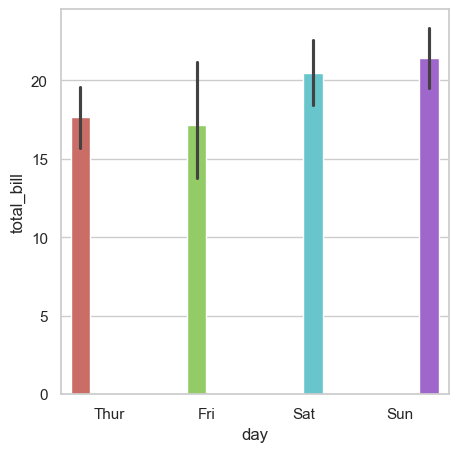

In [7]:
sns.set_theme(style='whitegrid', rc={'figure.figsize': (5, 5)})

sns.barplot(palette='hls',
            data=df,
            x='day',
            y='total_bill',
            estimator='mean',
            hue='day'
            )
plt.show()

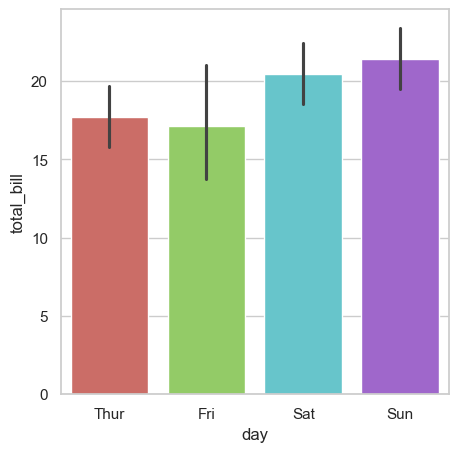

In [8]:
sns.set_theme(style='whitegrid', rc={'figure.figsize': (5, 5)})

sns.barplot(palette='hls',
            data=df,
            x='day',
            y='total_bill',
            estimator='mean',
            hue='day',
            dodge=False
            )
plt.show()

---

Seaborn Barplot: 오차 막대(Error Bar)의 이해
1. 막대 높이의 의미
- `estimator='mean'`: 각 범주별(예: 요일별) `total_bill` 데이터의 **산술 평균**을 나타냅니다.

---

2. 검은색 선: 오차 막대 (Error Bar) 그래프 상단의 검은색 수직 선은 통계학적으로 평균의 불확실성(변동성)을 나타냅니다.
- **신뢰 구간 (Confidence Interval):** 기본적으로 **95% 신뢰 구간**을 표시하며, "실제 모집단의 평균이 이 구간 안에 존재할 확률이 95%이다"라는 의미입니다.
- **데이터 해석의 척도:**
    - **선이 길다:** 데이터의 편차가 크거나 표본($n$)이 적어 평균을 확신하기 어렵습니다.
    - **선이 짧다:** 데이터가 평균 주변에 밀집되어 있어 결과가 비교적 안정적입니다.

---

3. `errorbar` 파라미터 설정

    | **설정 옵션** | **코드 예시** | **시각적 효과 및 의미** |
    | :--- | :--- | :--- |
    | **95% 신뢰구간 (기본)** | `errorbar=('ci', 95)` | 통계적으로 가장 많이 쓰이는 구간 표시 |
    | **80% 신뢰 구간** | `errorbar=('ci', 80)` | 95% 설정보다 선의 길이가 짧아짐 |
    | **표준편차** | `errorbar='sd'` | 데이터가 실제 퍼진 정도(**Standard Deviation**)를 표현 |
    | **제거** | `errorbar=None` | 오차 막대 없이 깔끔한 막대 그래프만 출력 |

---
4. 통계적 원리 및 수식 95% 신뢰 구간은 표본의 크기와 변동성을 바탕으로 아래와 같이 계산됩니다.

    (1) 신뢰 구간 (CI) 공식

    $CI = \bar{x} \pm t_{\alpha / 2, n-1} \times \frac{s}{\sqrt{n}}$
    - 표본의 개수($n$)가 충분히 클 경우, $t$값은 약 **1.96** (표준정규분포 기준)을 사용합니다.
    
    (2) 주요 기호 설명

    | **기호** | **의미** | **역할** |
    | :--- | :--- | :--- |
    | $\bar{x}$ | **표본 평균** | 막대의 실제 높이 |
    | $s$ | **표본 표준편차** | 개별 데이터들이 평균에서 떨어진 정도 |
    | $n$ | **표본 개수** | 표본이 많을수록 평균의 정확도가 올라가 오차 막대가 짧아짐 |
    | $\frac{s}{\sqrt{n}}$ | **표준오차 (SE)** | 표본 평균이 모평균과 얼마나 차이 나는지 나타내는 지표 |
    | $t_{n/2,n-1}$ | **t-분포 임계값** | 신뢰 수준(95%, 80% 등)에 따라 결정되는 상수 |

    (3) 신뢰 구간($CI$) 공식에서 표준편차($s$)가 커지거나, 표본 수($n$)가 작아지면 오차 범위가 커지게 됩니다.

<br>

---
위 그래프의 검은색 선 해석
- 중심점: 막대의 가장 윗부분은 해당 그룹(요일)의 평균값입니다.
- 선 전체의 길이: 이 선은 통계적으로 계산된 오차의 범위를 나타냅니다.
- 의미: "우리가 가진 이 표본 데이터를 바탕으로 추측하건대, 전체 데이터(모집단)의 진짜 평균은 95%의 확률로 이 검은색 선 범위 안에 있을 것이다"라는 뜻입니다.

---
Seaborn에서 기본적으로 제공되는 내장 컬러 팔레트(Built-in Palette)
| 팔레트 이름       | 분위기     | 특징                        |
| ------------ | ------- | ------------------------- |
| `deep`       | 차분함, 표준 | 가장 범용적이며 신뢰감을 주는 색상       |
| `muted`      | 부드러움    | `deep`보다 채도가 낮아 파스텔 느낌을 줌 |
| `bright`     | 선명함     | 강조하고 싶을 때 사용하는 아주 밝은 색상   |
| `dark`       | 어두움     | 전체적으로 톤이 낮아 무거운 느낌을 줌     |
| `colorblind` | 범용성     | 색맹·색약인 분들도 구분하기 쉽게 설계된 색상 |

'deep' 팔레트는 별도의 설정을 하지 않았을 때 Seaborn이 가장 먼저 사용하는 표준 색상입니다.

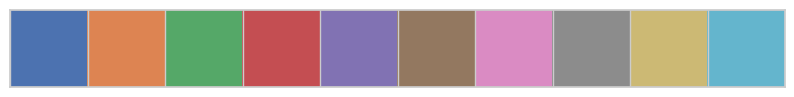

In [9]:
deep_colors10 = sns.color_palette('deep')
sns.palplot(deep_colors10)
plt.show()

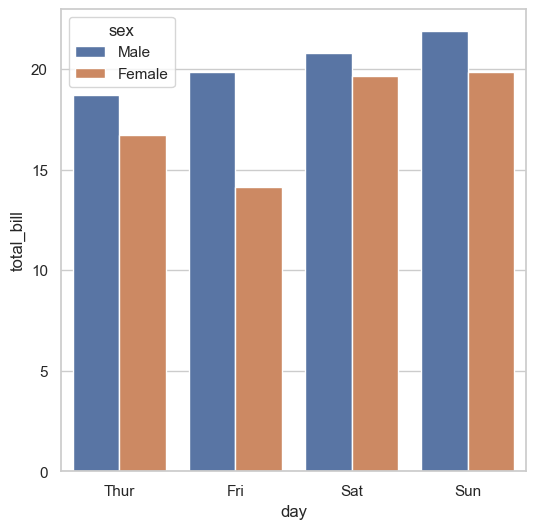

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))

sns.barplot(data=df,
            x='day',
            y='total_bill',
            estimator='mean',
            hue='sex',
            errorbar=None,
            palette='deep'
            )
plt.show()

In [11]:
df2 = df.pivot_table(index='day',
                    columns='sex',
                    values='total_bill',
                    aggfunc='mean',
                    observed=False
                    )
df2

sex,Male,Female
day,,
Thur,18.714667,16.715312
Fri,19.857000,14.145556
Sat,20.802542,19.680357
Sun,21.887241,19.872222


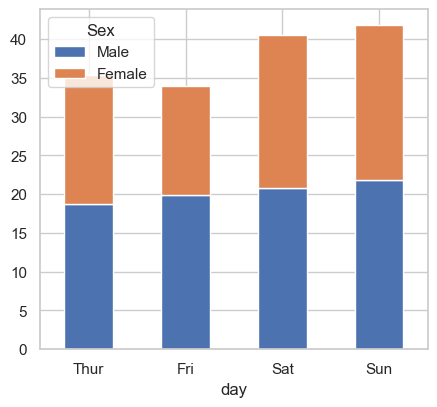

In [12]:
df2.plot.bar(stacked=True, rot=0)
plt.subplots_adjust(bottom=0.2) # 여백 아래 20%
plt.legend(loc='upper left', title='Sex')
plt.show()

---
선 그래프

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('flights') # 1949 ~ 1960
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


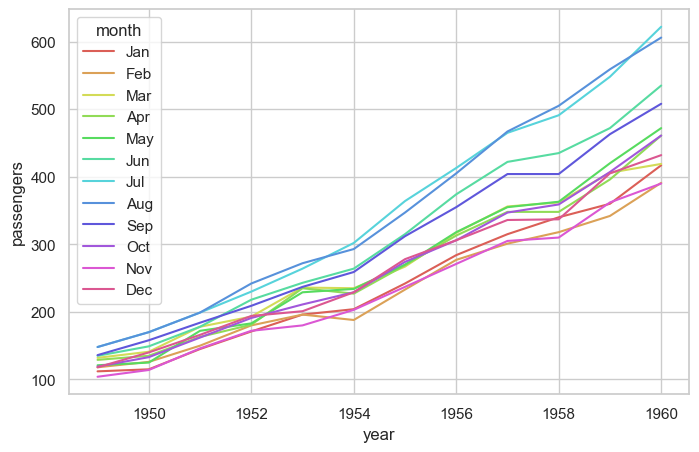

In [14]:
sns.set_theme(style='whitegrid', rc={'figure.figsize': (8, 5)})

sns.set_palette('hls', 12)

sns.lineplot(data=df,
            x='year',
            y='passengers',
            hue='month'
            )
plt.show()

시간 흐름(year)에 따라 선그래프가 변화 추세 파악에 적합합니다.
- 매년 항공기 탑승객의 수가 가파르게 증가하는 것을 확인할 수 있습니다.

<br>

---
상자그림

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/seoul_temp.csv')
df.head()

,날짜,평균기온,평균강수량,평균일조시간,평균습도,평균순간최대풍속
0,20231231,2.1,4.7,0.6,95.5,8.3
1,20231230,0.6,13.1,0.0,92.0,6.9
2,20231229,1.3,0.0,1.8,71.0,5.7
3,20231228,1.2,0.0,8.1,69.5,8.0
4,20231227,1.5,0.0,8.2,76.6,4.7


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        365 non-null    int64  
 1   평균기온      365 non-null    float64
 2   평균강수량     365 non-null    float64
 3   평균일조시간    365 non-null    float64
 4   평균습도      365 non-null    float64
 5   평균순간최대풍속  365 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 17.2 KB


In [17]:
df['month'] = (df['날짜'] - 20230000) // 100
df.head()

,날짜,평균기온,평균강수량,평균일조시간,평균습도,평균순간최대풍속,month
0,20231231,2.1,4.7,0.6,95.5,8.3,12
1,20231230,0.6,13.1,0.0,92.0,6.9,12
2,20231229,1.3,0.0,1.8,71.0,5.7,12
3,20231228,1.2,0.0,8.1,69.5,8.0,12
4,20231227,1.5,0.0,8.2,76.6,4.7,12


In [18]:
tmp = df.groupby('month').mean()
tmp

,날짜,평균기온,평균강수량,평균일조시간,평균습도,평균순간최대풍속
month,,,,,,
1,20230116.0,-1.522581,1.545161,6.158065,63.303226,8.038710
2,20230214.5,2.300000,0.035714,7.078571,58.900000,7.475000
3,20230316.0,9.780645,0.338710,7.735484,51.241935,8.612903
4,20230415.5,13.800000,3.230000,6.076667,59.933333,9.546667
5,20230516.0,19.522581,5.019355,7.600000,62.493548,8.893548
6,20230615.5,23.383333,6.520000,6.503333,72.433333,7.970000
7,20230716.0,26.706452,14.835484,4.712903,81.074194,8.712903
8,20230816.0,27.187097,9.616129,5.035484,76.351613,7.951613
9,20230915.5,23.663333,4.483333,5.236667,73.483333,6.980000


In [19]:
rank = tmp['평균기온'].rank()
rank

month
1      1.0
2      3.0
3      5.0
4      6.0
5      8.0
6      9.0
7     11.0
8     12.0
9     10.0
10     7.0
11     4.0
12     2.0
Name: 평균기온, dtype: float64

In [20]:
rank = rank - 1
print(rank)
print(type(rank))

month
1      0.0
2      2.0
3      4.0
4      5.0
5      7.0
6      8.0
7     10.0
8     11.0
9      9.0
10     6.0
11     3.0
12     1.0
Name: 평균기온, dtype: float64
<class 'pandas.Series'>


In [21]:
rank = rank.astype(int).to_list()
rank

[0, 2, 4, 5, 7, 8, 10, 11, 9, 6, 3, 1]

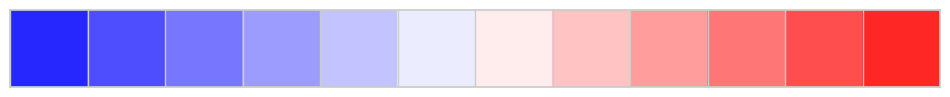

In [22]:
bwr_colors12 = sns.color_palette('bwr', 12)
sns.palplot(bwr_colors12)
plt.show()

In [23]:
sns.set_theme(style='white', rc={'figure.figsize': (7, 4)})

mycolor = sns.color_palette('bwr', 12)

print(mycolor)

[(0.14901960784313725, 0.14901960784313725, 1.0), (0.3058823529411765, 0.3058823529411765, 1.0), (0.4627450980392157, 0.4627450980392157, 1.0), (0.611764705882353, 0.611764705882353, 1.0), (0.7686274509803921, 0.7686274509803921, 1.0), (0.9254901960784314, 0.9254901960784314, 1.0), (1.0, 0.9254901960784314, 0.9254901960784314), (1.0, 0.7686274509803921, 0.7686274509803921), (1.0, 0.611764705882353, 0.611764705882353), (1.0, 0.46274509803921593, 0.46274509803921593), (1.0, 0.3058823529411765, 0.3058823529411765), (1.0, 0.14901960784313728, 0.14901960784313728)]


In [24]:
pd.Series(mycolor)[rank]

0     (0.14901960784313725, 0.14901960784313725, 1.0)
2       (0.4627450980392157, 0.4627450980392157, 1.0)
4       (0.7686274509803921, 0.7686274509803921, 1.0)
5       (0.9254901960784314, 0.9254901960784314, 1.0)
7       (1.0, 0.7686274509803921, 0.7686274509803921)
8         (1.0, 0.611764705882353, 0.611764705882353)
10      (1.0, 0.3058823529411765, 0.3058823529411765)
11    (1.0, 0.14901960784313728, 0.14901960784313728)
9     (1.0, 0.46274509803921593, 0.46274509803921593)
6       (1.0, 0.9254901960784314, 0.9254901960784314)
3         (0.611764705882353, 0.611764705882353, 1.0)
1       (0.3058823529411765, 0.3058823529411765, 1.0)
dtype: object

In [25]:
mycolor = pd.Series(mycolor)[rank].to_list()
mycolor

[(0.14901960784313725, 0.14901960784313725, 1.0),
 (0.4627450980392157, 0.4627450980392157, 1.0),
 (0.7686274509803921, 0.7686274509803921, 1.0),
 (0.9254901960784314, 0.9254901960784314, 1.0),
 (1.0, 0.7686274509803921, 0.7686274509803921),
 (1.0, 0.611764705882353, 0.611764705882353),
 (1.0, 0.3058823529411765, 0.3058823529411765),
 (1.0, 0.14901960784313728, 0.14901960784313728),
 (1.0, 0.46274509803921593, 0.46274509803921593),
 (1.0, 0.9254901960784314, 0.9254901960784314),
 (0.611764705882353, 0.611764705882353, 1.0),
 (0.3058823529411765, 0.3058823529411765, 1.0)]

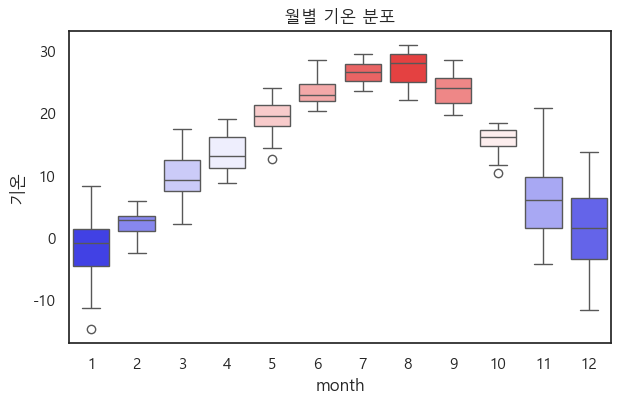

In [26]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(data=df,
            x='month',
            y='평균기온',
            hue='month',
            legend=None,
            palette=mycolor,
            ).set(title='월별 기온 분포')
plt.ylabel('기온')
plt.subplots_adjust(bottom=0.1)
plt.show()

---
히트맵(Heatmap)은 데이터의 값을 색상의 강도(밝기·색상) 로 표현하는 시각화 그래프입니다.
- 마치 열화상 카메라로 온도를 측정했을 때 뜨거운 곳은 붉게, 차가운 곳은 푸르게 표시되는 것과 같은 원리라고 이해하면 쉽습니다.

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [28]:
df = flights.pivot_table(index='month',
                        columns='year',
                        values='passengers',
                        aggfunc='mean',
                        observed=False
                        )
df.head()

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0


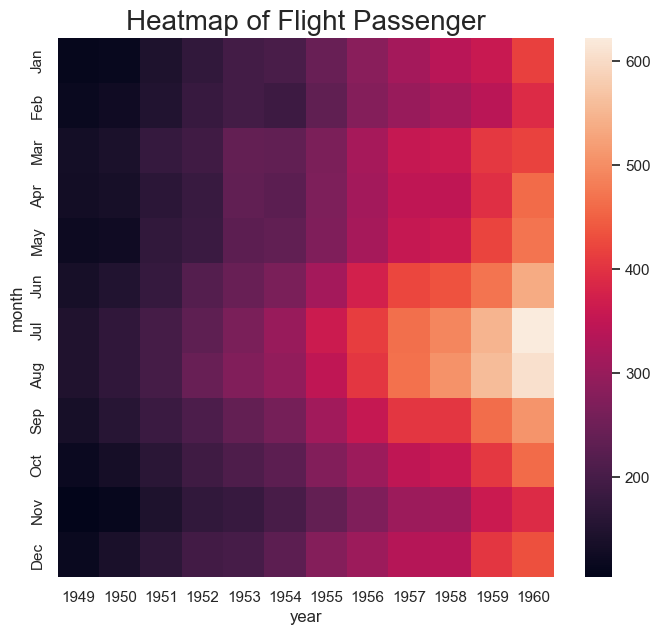

In [29]:
sns.set_theme(rc={'figure.figsize': (8, 7)})
sns.heatmap(df).set_title('Heatmap of Flight Passenger', fontsize=20)
plt.show()

- 색이 밝을 수록 탑승객 수가 많고 색이 어두울 수록 탑승객 수가 적습니다.
- 해가 갈 수록 색이 밝아 지는 경향을 볼 수 있습니다.
- 특히 7, 8월의 탑승객 수 변화는 다른 달과 비교했을 때 증가 속도가 더 빠릅니다.
- 이를 통해 7월과 8월이 성수기라고 해석할 수 있습니다.